In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

For the purpose of this subtask, I have used the ml-latest-small dataset of 100,000 datarows. The dataset is displayed in upcoming tabs. The dataset provides the rating in terms of stars 0-5, where, 0 means the user has not rated the movie.

In [2]:
ratings = pd.read_csv("./ml-latest-small/ratings.csv")
movies = pd.read_csv("./ml-latest-small/movies.csv")

### EDA

In this section, I have performed EDA on the given dataset.

In [3]:
ratings_count = len(ratings)
users_count = ratings['userId'].nunique()
movies_count = ratings['movieId'].nunique()

max_possibile = users_count * movies_count

sparsity_of_matrix = 1 - (ratings_count / max_possibile)

print(f"Sparsity of Matrix: {sparsity_of_matrix}")


Sparsity of Matrix: 0.9830003169443864


User-Item Matrix is 98.3% sparse. for this case. Therefore collaborative filtering using second method is highly appropriate. But, as per the assignment, we will do both of them. 

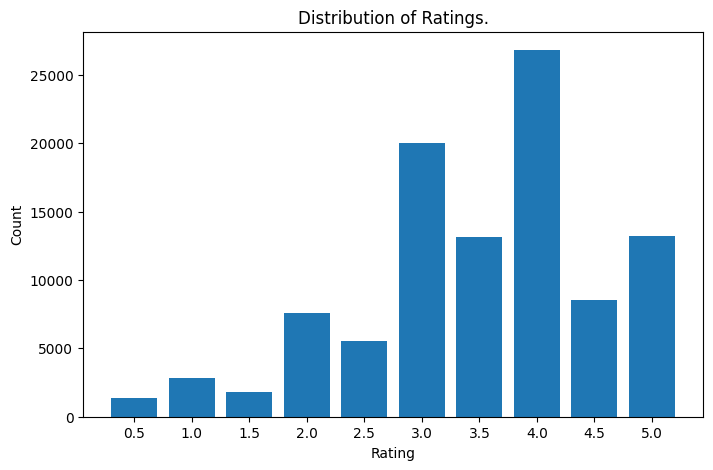

Ratings distribution:  rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


In [4]:
import matplotlib.pyplot as plt

ratings_distribution = ratings['rating'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(ratings_distribution.index.astype(str), ratings_distribution.values)

plt.xlabel('Rating')
plt.ylabel('Count')
plt.title("Distribution of Ratings.")
plt.show()
print("Ratings distribution: ", ratings['rating'].value_counts().sort_index())

Most ratings are at 4 stars. which tells, that the users are skewed in their rating. While ideally, the maximum stars should be at 2.5 or 3. Very few ratings are there for <2.5 stars. This shows the **selection bias** of the users

# Approach 1: Memory based

This approach uses a matrix to represent the first order user-item interaction. This approach directly computes the similarities between users and items to predict ratings. 

In [5]:
ratings = ratings[['userId', 'movieId', 'rating']]
train_df, test_df = train_test_split(ratings, test_size=0.2)

pivoting down the matrix gives me the matrix from the table, with each row representing a movie(item) and user as column.
I have kept the user at the column because, more than usually, we find the similarities between movies than users. As, a movie is part of the inner dimension of the matrix, the calculations become more efficient.

In [6]:
matrix_item_user = train_df.pivot(index='movieId', columns="userId", values="rating")

global_mean = train_df['rating'].mean()

filled_matrix = matrix_item_user.fillna(0)
filled_matrix

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,0.0,0.0,4.0,0.0,4.5,0.0,0.0,0.0,...,0.0,0.0,4.0,0.0,4.0,0.0,4.0,2.5,3.0,5.0
2,0.0,0.0,0.0,0.0,0.0,4.0,0.0,4.0,0.0,0.0,...,0.0,4.0,0.0,0.0,3.5,0.0,0.0,2.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193581,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
193583,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
193585,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
itm_similarity = cosine_similarity(filled_matrix)

itm_similarity = pd.DataFrame(itm_similarity, index=matrix_item_user.index, columns=matrix_item_user.index)


In [8]:
def pred_mem_based(user_id, item_id):
    if item_id not in itm_similarity.index or user_id not in matrix_item_user:
        return global_mean

    user_ratings = matrix_item_user[user_id]
    rated_movies = user_ratings.dropna()
    if rated_movies.empty:
        return global_mean

    similarities = itm_similarity.loc[item_id, rated_movies.index]

    sum_w = np.dot(similarities, rated_movies)
    sum = np.abs(similarities).sum()

    if sum == 0:
        return rated_movies.mean()

    return sum_w / sum

In [9]:
test_preds = [
    pred_mem_based(row.userId, row.movieId) 
    for row in test_df.itertuples()
]

In [10]:
rmse = np.sqrt(mean_squared_error(test_df['rating'], test_preds))

In [11]:
rmse

np.float64(0.9182122092731042)

I have obtained the rmse of 0.918 stars, meaning, my prediction misses actuality by 0.9 stars. It is considered poor for other methods. but, for the memory based approach, it is considered Above average.

# Approach 2
This is model based approach. I have used Matrix Factorization approach here as in the example. Here, we create latent spaces, where the relations are stored as *k* concepts. Using this, it becomes semantic rather than algorithmic for the prediction. So, it is more accurate because, we establish the 2nd order interaction between user-item which is better than the memory based approach. So, as there will be more semantic features here, more valuable this model is.

In [16]:
unique_users = train_df['userId'].unique()
unique_movies = train_df['movieId'].unique()

user_to_idx = {uid:i for i, uid in enumerate(unique_users)}
movie_to_idx = {uid: i for i, uid in enumerate(unique_movies)}

num_users = len(unique_users)
num_movies = len(unique_movies)

In [17]:
train_df['u_idx'] = train_df['userId'].map(user_to_idx)
train_df['m_idx'] = train_df['movieId'].map(movie_to_idx)

In [18]:
import time
from sklearn.metrics import mean_squared_error

In [75]:
n_factors = 18
lr = 0.002
reg = 0.01
n_epochs = 30

Used the global biases to represent the observed bias at the user user level and movi movie level. Also, using global mean delivers the headstart for the prediction. Means, the average from user perspective is established.

In [76]:
global_mean = train_df['rating'].mean()

b_u = np.zeros(num_users)
b_i = np.zeros(num_movies)

P = np.random.normal(scale=1./n_factors, size=(num_users, n_factors))
Q = np.random.normal(scale=1./n_factors, size=(num_movies, n_factors))

train_data = train_df[['u_idx', 'm_idx', 'rating']].values

In [77]:
# Training
for epoch in range(n_epochs):

    np.random.shuffle(train_data)

    for row in train_data:
        u = int(row[0])
        m = int(row[1])
        r_ui = int(row[2])

        prediction = global_mean + b_u[u] + b_i[m] + np.dot(P[u], Q[m])

        error = r_ui - prediction

        b_u[u] += lr * (error - reg * b_u[u])
        b_i[m] += lr * (error - reg * b_i[m])

        temp_Pu = P[u].copy()

        P[u] += lr * (error * Q[m] - reg * b_u[u])
        Q[m] += lr * (error * temp_Pu - reg * b_i[m])
    print(f"Epoch {epoch+1}/{n_epochs}")

Epoch 1/30
Epoch 2/30
Epoch 3/30
Epoch 4/30
Epoch 5/30
Epoch 6/30
Epoch 7/30
Epoch 8/30
Epoch 9/30
Epoch 10/30
Epoch 11/30
Epoch 12/30
Epoch 13/30
Epoch 14/30
Epoch 15/30
Epoch 16/30
Epoch 17/30
Epoch 18/30
Epoch 19/30
Epoch 20/30
Epoch 21/30
Epoch 22/30
Epoch 23/30
Epoch 24/30
Epoch 25/30
Epoch 26/30
Epoch 27/30
Epoch 28/30
Epoch 29/30
Epoch 30/30


In [78]:
def predict_mat_fac(user_id, movie_id):
    if user_id not in user_to_idx or movie_id not in movie_to_idx:
        return global_mean

    u = user_to_idx[user_id]
    m = movie_to_idx[movie_id]

    pred = global_mean + b_u[u] + b_i[m] + np.dot(P[u], Q[m])

    if np.isnan(pred): 
        return global_mean

    if pred < 0.5: return 0.5
    if pred > 5.0: return 5.0 

    return pred


In [79]:

test_preds_2 = [
    predict_mat_fac(row.userId, row.movieId) for row in test_df.itertuples()
]

In [80]:
rmse_mf = mean_squared_error(test_df['rating'], test_preds_2)
rmse_mf

0.7974213034838927

The score is better than the memory based implementation due to semantic lookup, rather than algorithmic comparision

In [81]:
train_preds_2 = [
    predict_mat_fac(row.userId, row.movieId) for row in train_df.itertuples()
]

rmse_mf_tr = mean_squared_error(train_df['rating'], train_preds_2)
rmse_mf_tr

0.6866883939785406

,Approach,Test RMSE
0,Memory-Based (Item-Item),0.918212
1,Model-Based (Matrix Factorization),0.892984


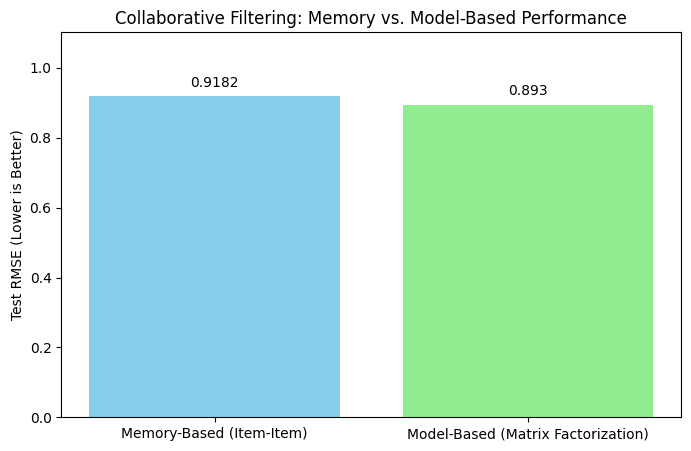

In [82]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

final_rmse_mf = np.sqrt(rmse_mf)

results_df = pd.DataFrame({
    'Approach': ['Memory-Based (Item-Item)', 'Model-Based (Matrix Factorization)'],
    'Test RMSE': [rmse, final_rmse_mf]
})
display(results_df)

plt.figure(figsize=(8, 5))
bars = plt.bar(results_df['Approach'], results_df['Test RMSE'], color=['skyblue', 'lightgreen'])
plt.ylabel('Test RMSE (Lower is Better)')
plt.title('Collaborative Filtering: Memory vs. Model-Based Performance')
plt.ylim(0, max(results_df['Test RMSE']) * 1.2)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 4), ha='center', va='bottom')

plt.show()

To determine the values more accurately, we have to go for higher order complexities. Thus, originated DCNs and DFMs and DLRMs.